In [1]:
import os

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
TICKERS = ["RYAAY", "LHA.DE", "AF.PA", "IAG.L"]
OUTPUT_DIR = "output"


In [3]:
def _get_row(df, candidates):
    """Find the first matching row label from a list of possible names"""
    
    for name in candidates:
        if name in df.index:
            return df.loc[name]
    return None
 

In [4]:
def fetch_company_data(ticker):
    """Pull balance sheet + income statement for one ticker and return"""
    t = yf.Ticker(ticker)
    bs = t.balance_sheet
    inc = t.financials

    if bs.empty or inc.empty:
        raise ValueError(f"No data returned for {ticker} (check ticker or network access)")

    data = {
        "ticker": ticker,
        "receivables": _get_row(bs, ["Accounts Receivable", "Receivables", "Net Receivables"]),
        "payables": _get_row(bs, ["Accounts Payable", "Payables", "Payables And Accrued Expenses"]),
        "inventory": _get_row(bs, ["Inventory", "Inventories"]),
        "current_assets": _get_row(bs, ["Current Assets", "Total Current Assets"]),
        "current_liabilities": _get_row(bs, ["Current Liabilities", "Total Current Liabilities"]),
        "cash": _get_row(bs, ["Cash And Cash Equivalents", "Cash Cash Equivalents And Short Term Investments"]),
        "revenue": _get_row(inc, ["Total Revenue", "Revenue"]),
        "cogs": _get_row(inc, ["Cost Of Revenue", "Reconciled Cost Of Revenue", "Cost Of Goods Sold"]),
    }
    return data


def _num(x):
    """Latest value of a line item as a float, or None if missing/NaN.

    yfinance leaves NaN in cells it could not fill, and NaN is truthy - so the
    guards below have to test for it explicitly rather than rely on `if x`.
    """
    if x is None or len(x) == 0:
        return None
    v = x.iloc[0]
    return None if pd.isna(v) else float(v)


def _ratio(numerator, denominator, scale=1.0, ndigits=2):
    """Guarded division - None unless both sides exist and the denominator is non-zero."""
    if numerator is None or denominator is None or denominator == 0:
        return None
    return round(numerator / denominator * scale, ndigits)


def calculate_ratios(data, days=365):
    """Compute DSO, DPO, DIO, CCC, current/quick/cash ratio from raw line items.
    Uses the most recent fiscal year (single-period average, not avg of two years,
    to keep it simple for a first-pass model)."""
    receivables = _num(data["receivables"])
    payables = _num(data["payables"])
    inventory = _num(data["inventory"])
    current_assets = _num(data["current_assets"])
    current_liabilities = _num(data["current_liabilities"])
    cash = _num(data["cash"])
    revenue = _num(data["revenue"])
    cogs = _num(data["cogs"])

    results = {"ticker": data["ticker"]}

    results["DSO"] = _ratio(receivables, revenue, days, 1)
    results["DPO"] = _ratio(payables, cogs, days, 1)
    # Airlines carry little or no inventory - a missing line item means zero days
    # here, not "unknown", so DIO and CCC stay computable.
    results["DIO"] = 0.0 if inventory is None else _ratio(inventory, cogs, days, 1)

    if None not in (results["DSO"], results["DIO"], results["DPO"]):
        results["CCC"] = round(results["DSO"] + results["DIO"] - results["DPO"], 1)
    else:
        results["CCC"] = None

    results["Current Ratio"] = _ratio(current_assets, current_liabilities)
    quick_assets = None if current_assets is None else current_assets - (inventory or 0)
    results["Quick Ratio"] = _ratio(quick_assets, current_liabilities)
    results["Cash Ratio"] = _ratio(cash, current_liabilities)

    return results

In [5]:
def build_comparison(tickers, days=365):
    """Fetch + compute for every ticker. A failure on one name is reported and skipped
    rather than killing the whole run."""
    rows = []
    for ticker in tickers:
        try:
            rows.append(calculate_ratios(fetch_company_data(ticker), days=days))
        except Exception as exc:
            print(f"[skip] {ticker}: {exc}")

    if not rows:
        raise RuntimeError("No tickers returned usable data")

    return pd.DataFrame(rows).set_index("ticker")


ratios = build_comparison(TICKERS)

os.makedirs(OUTPUT_DIR, exist_ok=True)
ratios.to_csv(os.path.join(OUTPUT_DIR, "working_capital_ratios.csv"))

ratios

,DSO,DPO,DIO,CCC,Current Ratio,Quick Ratio,Cash Ratio
ticker,,,,,,,
RYAAY,1.0,18.5,0.1,-17.4,0.90,0.90,0.32
LHA.DE,22.2,46.1,17.3,-6.6,0.81,0.73,0.06
AF.PA,24.5,39.6,14.4,-0.7,0.62,0.56,0.28
IAG.L,14.8,42.7,10.3,-17.6,0.70,0.66,0.40


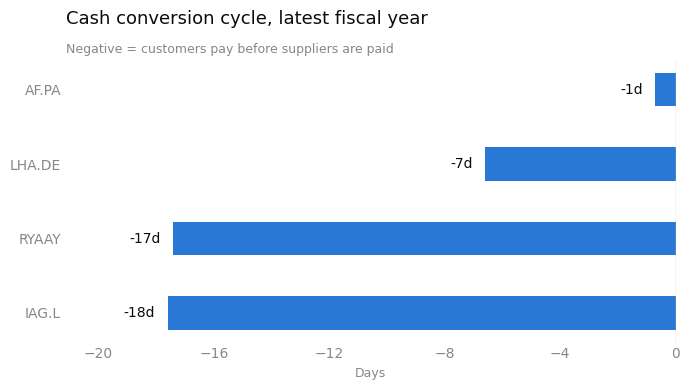

In [6]:
POSITIVE = "#e34948"  # cash tied up
NEGATIVE = "#2a78d6"  # cash released - the airline is paid before it flies
MUTED = "#898781"
BASELINE = "#c3c2b7"
INK = "#0b0b0b"

ccc = ratios["CCC"].dropna().sort_values()

fig, ax = plt.subplots(figsize=(7, 0.55 * len(ccc) + 1.8))
bars = ax.barh(
    ccc.index,
    ccc.values,
    height=0.45,
    color=[NEGATIVE if v < 0 else POSITIVE for v in ccc.values],
)

# direct-label every bar so the sign is never carried by color alone
span = max(abs(ccc.min()), abs(ccc.max())) or 1
for bar, value in zip(bars, ccc.values):
    offset = 0.025 * span
    ax.text(
        value + (offset if value >= 0 else -offset),
        bar.get_y() + bar.get_height() / 2,
        f"{value:,.0f}d",
        va="center",
        ha="left" if value >= 0 else "right",
        color=INK,
        fontsize=10,
    )

ax.axvline(0, color=BASELINE, linewidth=1)
ax.set_title(
    "Cash conversion cycle, latest fiscal year",
    fontsize=13, loc="left", color=INK, pad=26,
)
ax.text(
    0, 1.015, "Negative = customers pay before suppliers are paid",
    transform=ax.transAxes, fontsize=9, color=MUTED, va="bottom",
)
ax.set_xlabel("Days", color=MUTED, fontsize=9)
ax.xaxis.set_major_locator(plt.MaxNLocator(nbins=7, integer=True))
ax.tick_params(colors=MUTED, labelsize=10, length=0)
ax.margins(x=0.2)
for side in ("top", "right", "bottom", "left"):
    ax.spines[side].set_visible(False)

fig.tight_layout()
fig.savefig(os.path.join(OUTPUT_DIR, "ccc.png"), dpi=200, bbox_inches="tight")
plt.show()